# scRNA-seq Dimensionality Reduction

This notebook continues from the feature-selection workflow and creates low-dimensional representations of the single-cell dataset.

Place the feature-selected input dataset at:

```text
data/s4d8_feature_selection.h5ad
```

The workflow:

1. Loads the feature-selected `AnnData` object.
2. Uses the Scran-normalized expression matrix.
3. Computes PCA using the highly deviant genes.
4. Computes t-SNE from the PCA representation.
5. Builds a neighborhood graph and computes UMAP.
6. Inspects quality-control metrics on the UMAP.
7. Saves the updated object to `results/s4d8_dimensionality_reduction.h5ad`.


## Environment setup

In [ ]:
# Import Scanpy and define reusable paths
from pathlib import Path

import scanpy as sc

# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)


## Load the feature-selected dataset

In [ ]:
# Load the AnnData object created in the feature-selection notebook
DATA_PATH = Path("data/s4d8_feature_selection.h5ad")

adata = sc.read_h5ad(DATA_PATH)
adata


AnnData object with n_obs × n_vars = 14814 × 20121
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'soupx_groups', 'scDblFinder_score', 'scDblFinder_class', 'size_factors'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
    layers: 'analytic_pearson_residuals', 'counts', 'log1p_norm', 'scran_normalization', 'soupX_counts'

## Select the normalized expression representation

In [ ]:
# Use the Scran-normalized expression matrix for dimensionality reduction
adata.X = adata.layers["scran_normalization"]


## Principal component analysis

In [ ]:
# Reuse the highly deviant genes as Scanpy's highly variable gene mask
adata.var["highly_variable"] = adata.var["highly_deviant"]


In [ ]:
# Compute PCA using the selected genes
sc.pp.pca(
    adata,
    svd_solver="arpack",
    mask_var="highly_variable",
)


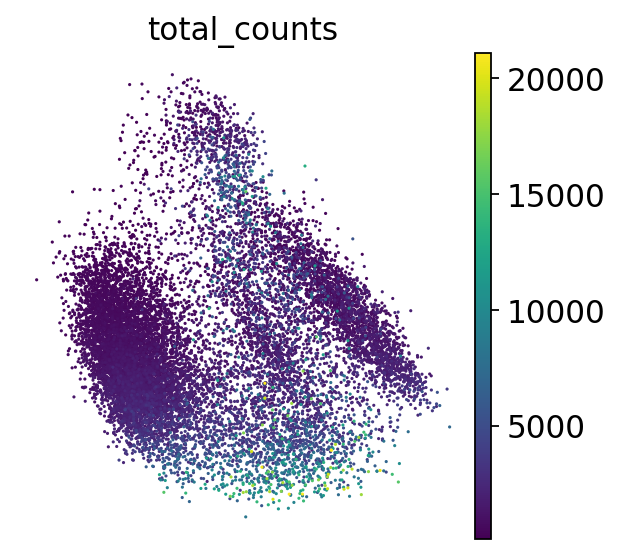

In [ ]:
# Visualize the first two principal components
sc.pl.pca_scatter(
    adata,
    color="total_counts",
)


## t-SNE

In [ ]:
# Compute t-SNE from the PCA representation
sc.tl.tsne(
    adata,
    use_rep="X_pca",
)


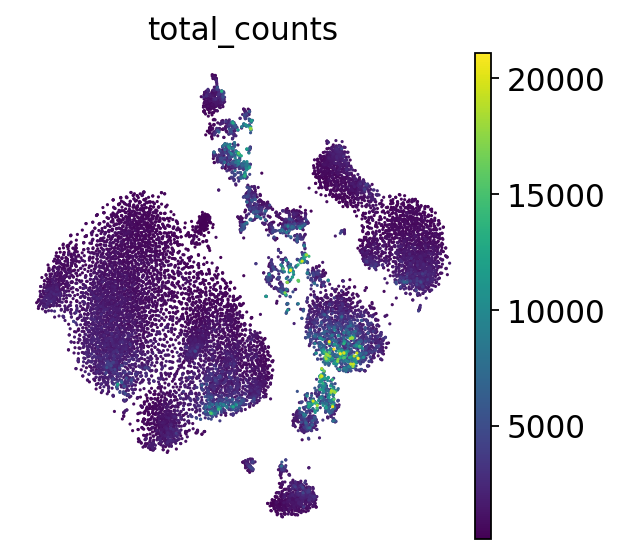

In [ ]:
# Visualize the t-SNE embedding
sc.pl.tsne(
    adata,
    color="total_counts",
)


## UMAP

In [ ]:
# Build the neighborhood graph
sc.pp.neighbors(adata)


In [ ]:
# Compute the UMAP embedding
sc.tl.umap(adata)


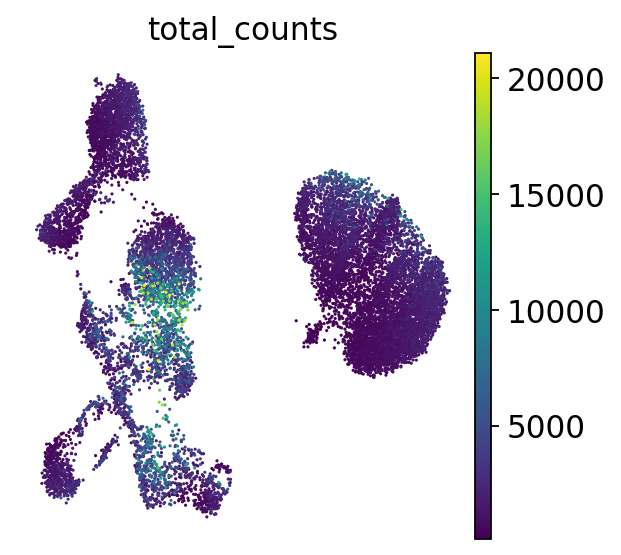

In [ ]:
# Visualize the UMAP embedding
sc.pl.umap(
    adata,
    color="total_counts",
)


## Inspect quality-control metrics

In [ ]:
# Inspect technical and doublet-related metrics on the same UMAP layout
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "pct_counts_mt",
        "scDblFinder_score",
        "scDblFinder_class",
    ],
)


## Save the dimensionality-reduction results

In [ ]:
# Save the AnnData object with PCA, t-SNE, UMAP, and neighbor-graph results
OUTPUT_PATH = Path("results/s4d8_dimensionality_reduction.h5ad")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

adata.write_h5ad(OUTPUT_PATH)
